## Basic Steps

1. Run a baseline training script to build a speech commands model.
2. Add in your custom word to the training and test/validation sets.
   - Modify labels, shape of your output tensor in the model.
   - Make sure that feature extractor for the model aligns with the feature extractor
     used in the arduino code.
3. Re-train model. => TF Model using floating-point numbers, that recognizes Google word and custom word.
4. Quantize the model and convert to TFlite. => keyword_model.tflite file
5. Convert tflite to .c file, using xxd => model_data.cc
6. Replace contents of existing micro_features_model.cpp with output of xxd.

All of the above steps are done in this notebook for the commands 'left', 'right'.

7. In micro_speech.ino, modify micro_op_resolver (around line 80) to add any necessary operations (DIFF_FROM_LECTURE)
8. In micro_features_model_settings.h, modify kSilenceIndex and kUnknownIndex, depending on
where you have them in commands.  
  - Commands = ['left', 'right', '_silence', '_unknown'] => kSilenceIndex=2, kUnknownIndex=3
9. In micro_features_model_settings.cpp, modify kCategoryLabels to correspond to commands in this script.
10. In micro_features_micro_model_settings.h, set kFeatureSliceDurationMs, kFeatureSliceStrideMs to match what is passed to microfrontend as window_size, window_step, respectively.
11. Rebuild Arduino program, run it, recognize the two target words.
12. Experiment with model architecture, training parameters/methods, augmentation, more data-gathering, etc.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow.keras import Input, layers
from tensorflow.keras import models
from tensorflow.lite.experimental.microfrontend.python.ops import audio_microfrontend_op as frontend_op
print(tf.__version__)

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
# from tqdm import tqdm # replace with this if moving out of notebook

import os
import pathlib

from datetime import datetime as dt

from IPython import display

import platform

2.19.0


In [ ]:
# Set seed for experiment reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [ ]:
APPLE_SILICON = platform.processor() == 'arm'
i16min = -2**15
i16max = 2**15-1
fsamp = 16000
wave_length_ms = 1000
wave_length_samps = int(wave_length_ms*fsamp/1000)
window_size_ms=64
window_step_ms=48
num_filters = 32
use_microfrontend = True
## uncomment exactly one of these (and not full-speech-ds)
dataset = 'custom'
# dataset = 'full-speech-ds' # use the full speech commands as a pre-built TF dataset
# dataset = 'full-speech-files' # use the full speech commands stored as files

commands = ['orange', 'marvin', 'noise'] ## Change this line for your custom keywords

# limit the instances of each command in the training set to simulate limited data
max_wavs_0 = 200  # use no more than ~ samples of commands[0]
max_wavs_1 = 200  # use no more than ~ samples of commands[1]

silence_str = "_silence"
unknown_str = "_unknown"
EPOCHS = 15

print(f"FFT window length = {window_size_ms * fsamp / 1000}")

might_be = {True:"IS", False:"IS NOT"}

FFT window length = 1024.0


Apply the frontend to an example signal.

In [ ]:
if dataset == 'custom':
    data_dir = pathlib.Path("/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples")
    print("Using custom dataset:", data_dir)

elif dataset == 'mini-speech':
    data_dir = pathlib.Path(os.path.join(os.getenv("HOME"), 'data/mini_speech_commands'))
    if not data_dir.exists():
        tf.keras.utils.get_file(
            'mini_speech_commands.zip',
            origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
            extract=True, cache_dir='.', cache_subdir='data')

elif dataset == 'full-speech-files':
    data_dir = pathlib.Path(os.path.join(os.getenv("HOME"), 'data', 'speech_commands_files_0.2'))

elif dataset == 'full-speech-ds':
    raise RuntimeError("full-speech-ds is not really supported yet")

Using custom dataset: /content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples


In [ ]:
# wget http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz

In [ ]:
data_dir

PosixPath('/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples')

In [ ]:
label_list = commands.copy()
print('label_list:', label_list)

label_list: ['orange', 'marvin', 'noise']


In [ ]:
if dataset == 'custom':
    # filenames = tf.io.gfile.glob(str(data_dir) + '/*/*.wav')
    # filenames = tf.io.gfile.glob(str(data_dir) + os.sep + '*' + '/' + '*.wav')
    filenames = tf.io.gfile.glob(str(data_dir) + '/*/*.wav')

    # with the next commented-out line, you can choose only files for words in label_list
    # filenames = tf.concat([tf.io.gfile.glob(str(data_dir) + '/' + cmd + '/*') for cmd in label_list], 0)
    filenames = tf.random.shuffle(filenames)
    num_samples = len(filenames)
    print('Number of total examples:', num_samples)
    # print('Number of examples per label:',
    #       len(tf.io.gfile.listdir(str(data_dir/commands[0]))))
    print('Example file tensor:', filenames[0])

Number of total examples: 462
Example file tensor: tf.Tensor(b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f9318c93_nohash_0.wav', shape=(), dtype=string)


In [ ]:
# x = [tf.io.gfile.glob(str(data_dir) + '/' + cmd + '/*') for cmd in label_list]

In [ ]:
# label_list[0,1] are
# fn_targets = tf.concat([tf.io.gfile.glob(str(data_dir) + '/' + cmd + '/*') for cmd in label_list[2:]], 0);

In [ ]:
# Not really necessary, but just look at a few of the files to make sure that
# they're the correct files, shuffled, etc.
for i in range(10):
    print(filenames[i].numpy().decode('utf8'))

/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f9318c93_nohash_0.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f1d36c53_nohash_2.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange/orange_E207FB25_004.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f816db77_nohash_0.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise/noise_960AFA2B_002.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise/noise_7E7645AC_033.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise/noise_6B79F8FB_003.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f42e234b_nohash_0.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange/orange_4D4B213D_018.wav
/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise/noise_960AFA2B_008.

In [ ]:
if dataset == 'custom':
    num_train_files = int(0.7 * num_samples)
    num_val_files = int(0.15 * num_samples)
    num_test_files = num_samples - num_train_files - num_val_files

    train_files = filenames[:num_train_files]
    val_files = filenames[num_train_files:num_train_files + num_val_files]
    test_files = filenames[-num_test_files:]

elif dataset == 'mini-speech':
    print('Using mini-speech')
    num_train_files = int(0.8*num_samples)
    num_val_files = int(0.1*num_samples)
    num_test_files = num_samples - num_train_files - num_val_files
    train_files = filenames[:num_train_files]
    val_files = filenames[num_train_files: num_train_files + num_val_files]
    test_files = filenames[-num_test_files:]

In [ ]:
print(train_files[:5])
print(val_files[:5])
print(test_files[:5])

tf.Tensor(
[b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f9318c93_nohash_0.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f1d36c53_nohash_2.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange/orange_E207FB25_004.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin/f816db77_nohash_0.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise/noise_960AFA2B_002.wav'], shape=(5,), dtype=string)
tf.Tensor(
[b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange/orange_2AA346EF_015.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise/noise_7E7645AC_029.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange/orange_4D4B213D_021.wav'
 b'/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange/orange_4D4B213D_003.wav'
 b'/co

In [ ]:
def decode_audio(audio_binary):
  audio, _ = tf.audio.decode_wav(audio_binary)
  return tf.squeeze(audio, axis=-1)

In [ ]:
# @tf.function
def get_label(file_path):
  parts = tf.strings.split(file_path, os.path.sep)
  in_set = tf.reduce_any(parts[-2] == label_list)
  label = tf.cond(in_set, lambda: parts[-2], lambda: tf.constant(unknown_str))
  # print(f"parts[-2] = {parts[-2]}, in_set = {in_set}, label = {label}")
  # Note: You'll use indexing here instead of tuple unpacking to enable this
  # to work in a TensorFlow graph.
  return  label # parts[-2]

In [ ]:
def get_waveform_and_label(file_path):
  label = get_label(file_path)
  audio_binary = tf.io.read_file(file_path)
  waveform = decode_audio(audio_binary)
  return waveform, label

In [ ]:
#frontend_op.audio_microfrontend?

In [ ]:
def get_spectrogram(waveform):
  # Concatenate audio with padding so that all audio clips will be of the
  # same length (16000 samples)
  zero_padding = tf.zeros([wave_length_samps] - tf.shape(waveform), dtype=tf.int16)
  waveform = tf.cast(0.5*waveform*(i16max-i16min), tf.int16)  # scale float [-1,+1]=>INT16
  equal_length = tf.concat([waveform, zero_padding], 0)
  ## Make sure these labels correspond to those used in micro_features_micro_features_generator.cpp
  spectrogram = frontend_op.audio_microfrontend(equal_length, sample_rate=fsamp, num_channels=num_filters,
                                    window_size=window_size_ms, window_step=window_step_ms)
  return spectrogram


Function to convert each waveform in a set into a spectrogram, then convert those
back into a dataset using `from_tensor_slices`.  (We should be able to use
`wav_ds.map(get_spectrogram_and_label_id)`, but there is a problem with that process).
   

In [ ]:
def create_silence_dataset(num_waves, samples_per_wave, rms_noise_range=[0.01,0.2], silent_label='noise'):
    # create num_waves waveforms of white gaussian noise, with rms level drawn from rms_noise_range
    # to act as the "silence" dataset
    rng = np.random.default_rng()
    rms_noise_levels = rng.uniform(low=rms_noise_range[0], high=rms_noise_range[1], size=num_waves)
    rand_waves = np.zeros((num_waves, samples_per_wave), dtype=np.float32) # pre-allocate memory
    for i in range(num_waves):
        rand_waves[i,:] = rms_noise_levels[i]*rng.standard_normal(samples_per_wave)
    labels = [silent_label]*num_waves
    return tf.data.Dataset.from_tensor_slices((rand_waves, labels))

In [ ]:
def wavds2specds(waveform_ds, verbose=True):
  wav, label = next(waveform_ds.as_numpy_iterator())
  one_spec = get_spectrogram(wav)
  one_spec = tf.expand_dims(one_spec, axis=0)  # add a 'batch' dimension at the front
  one_spec = tf.expand_dims(one_spec, axis=-1) # add a singleton 'channel' dimension at the back

  num_waves = 0 # count the waveforms so we can allocate the memory
  for wav, label in waveform_ds:
    num_waves += 1
  print(f"About to create spectrograms from {num_waves} waves")
  spec_shape = (num_waves,) + one_spec.shape[1:]
  spec_grams = np.nan * np.zeros(spec_shape)  # allocate memory
  labels = np.nan * np.zeros(num_waves)
  idx = 0
  for wav, label in waveform_ds:
    if verbose and idx % 250 == 0:
      print(f"\r {idx} wavs processed", end='')
    spectrogram = get_spectrogram(wav)
    # TF conv layer expect inputs structured as 4D (batch_size, height, width, channels)
    # the microfrontend returns 2D tensors (freq, time), so we need to
    spectrogram = tf.expand_dims(spectrogram, axis=0)  # add a 'batch' dimension at the front
    spectrogram = tf.expand_dims(spectrogram, axis=-1) # add a singleton 'channel' dimension at the back
    spec_grams[idx, ...] = spectrogram
    new_label = label.numpy().decode('utf8')
    new_label_id = np.argmax(new_label == np.array(label_list))
    labels[idx] = new_label_id # for numeric labels
    # labels.append(new_label) # for string labels
    idx += 1
  labels = np.array(labels, dtype=int)
  output_ds = tf.data.Dataset.from_tensor_slices((spec_grams, labels))
  return output_ds

In [ ]:
train_files = tf.constant(train_files)
val_files = tf.constant(val_files)
test_files = tf.constant(test_files)

AUTOTUNE = tf.data.experimental.AUTOTUNE
num_train_files = len(train_files)
files_ds = tf.data.Dataset.from_tensor_slices(train_files)
waveform_ds = files_ds.map(get_waveform_and_label, num_parallel_calls=AUTOTUNE)
train_ds = wavds2specds(waveform_ds)

About to create spectrograms from 323 waves
 250 wavs processed

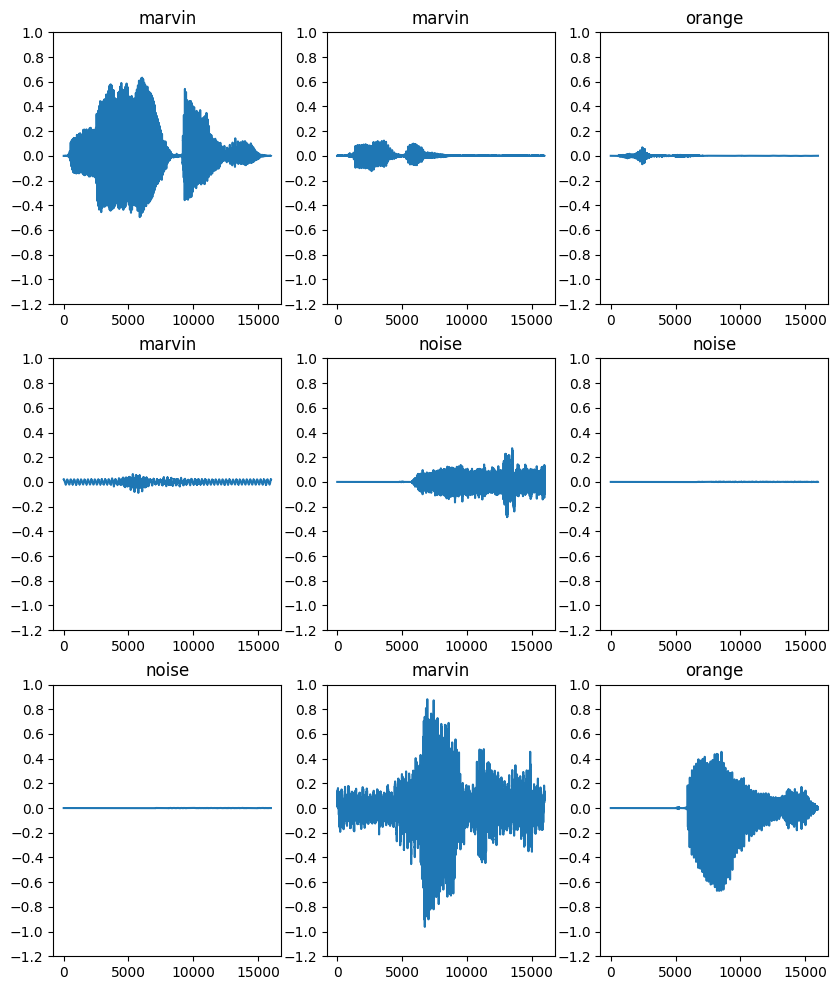

In [ ]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 12))
for i, (audio, label) in enumerate(waveform_ds.take(n)):
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  ax.plot(audio.numpy())
  ax.set_yticks(np.arange(-1.2, 1.2, 0.2))
  label = label.numpy().decode('utf-8')
  ax.set_title(label)

plt.show()

In [ ]:
for waveform, label in waveform_ds.take(1):
  label = label.numpy().decode('utf-8')
  spectrogram = get_spectrogram(waveform)

print('Label:', label)
print('Waveform shape:', waveform.shape)
print('Spectrogram shape:', spectrogram.shape)
print('Audio playback')
display.display(display.Audio(waveform, rate=16000))

Label: marvin
Waveform shape: (16000,)
Spectrogram shape: (20, 32)
Audio playback


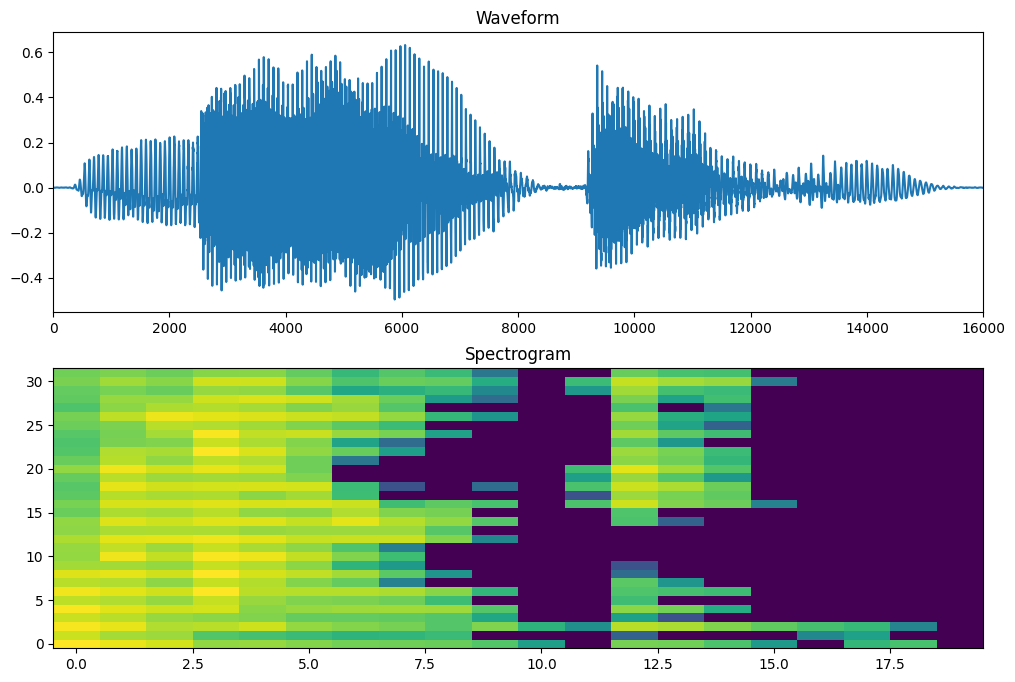

In [ ]:
def plot_spectrogram(spectrogram, ax):
  # transpose so that the time is
  # represented in the x-axis (columns).
  freq_bins = spectrogram.shape[1]
  time_dur = spectrogram.shape[0]
  X = np.arange(time_dur)
  Y = range(freq_bins)
  ax.pcolormesh(X, Y, spectrogram.T)

fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])
plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.show()

In [ ]:
spectrogram.numpy().shape

(20, 32)

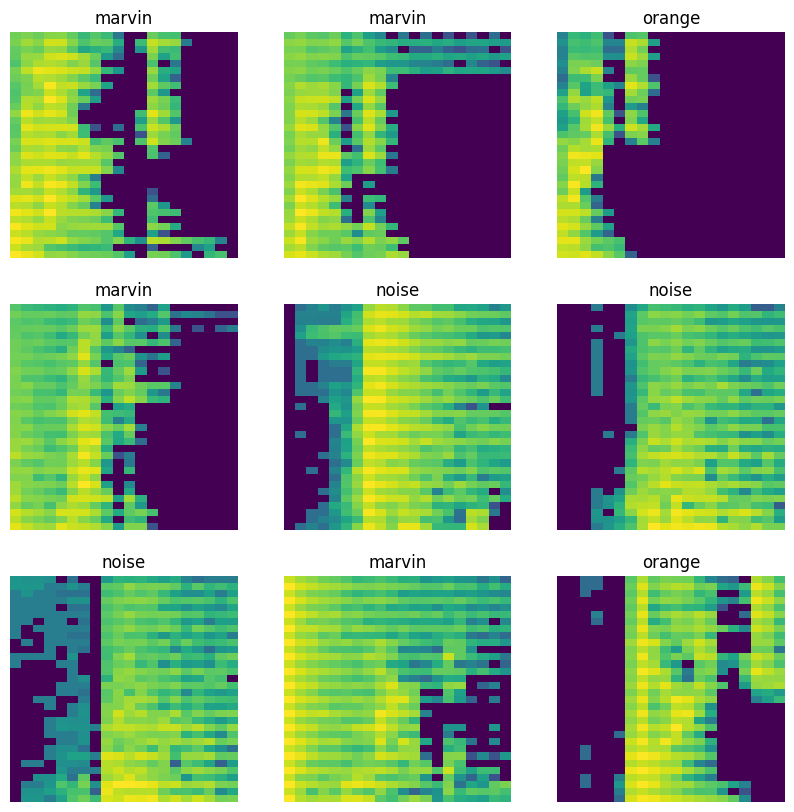

In [ ]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
for i, (spectrogram, label_id) in enumerate(train_ds.take(n)):
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  plot_spectrogram(np.squeeze(spectrogram.numpy()), ax)
  ax.set_title(label_list[int(label_id)])
  ax.axis('off')

plt.show()

In [ ]:
def copy_with_noise(ds_input, rms_level=0.25):
  rng = tf.random.Generator.from_seed(1234)
  wave_shape = tf.constant((wave_length_samps,))
  def add_noise(waveform, label):
    noise = rms_level*rng.normal(shape=wave_shape)
    zero_padding = tf.zeros([wave_length_samps] - tf.shape(waveform), dtype=waveform.dtype)
    waveform = tf.concat([waveform, zero_padding], 0)
    noisy_wave = waveform + noise
    return noisy_wave, label

  return ds_input.map(add_noise)

In [ ]:
# waveform_ds = augment_with_noise(waveform_ds)
count = 0
for w,l in waveform_ds:
  if w.shape != (16000,):
    print(f"element {count} has shape {w.shape}")
    break
  count += 1
print(count)

element 33 has shape (14118,)
33


In [ ]:
def pad_16000(waveform, label):
    zero_padding = tf.zeros([wave_length_samps] - tf.shape(waveform), dtype=waveform.dtype)
    waveform = tf.concat([waveform, zero_padding], 0)
    return waveform, label

In [ ]:
def count_labels(dataset):
    counts = {}
    for sample in dataset: # sample will be a tuple: (input, label) or (input, label, weight)
        lbl = sample[1]
        if lbl.dtype == tf.string:
            label = lbl.numpy().decode('utf-8')
        else:
            label = lbl.numpy()
        if label in counts:
            counts[label] += 1
        else:
            counts[label] = 1
    return counts

* standard dataset
    - dataset => (input_tensor, label)  
* weighted dataset
    - dataset => (input_tensor, label, weight)

In [ ]:
def ds_add_sample_weights(ds_input, weight_dict, default_weight=1.0):
  # build a tf hash table from the provided weight_dict
  table_init = tf.lookup.KeyValueTensorInitializer(
          # keys=tf.constant(, dtype=tf.string), # for string labels
          keys=tf.constant(list(weight_dict.keys()), dtype=tf.int32),
          values=tf.constant(list(weight_dict.values()), dtype=tf.float64)
          )
  weight_table = tf.lookup.StaticHashTable(table_init,
        default_value=tf.constant(default_weight, dtype=tf.float64),
        name="class_weight")
  # provide a mapping function to look up a weight and add it to the tuple
  def add_weight(value, label):
    # print("In add_weight. label is:")
    # print(label)
    weight = weight_table.lookup(tf.cast(label, dtype=tf.int32))
    return value, label, weight
  # actually map the dataset
  return ds_input.map(add_weight)

In [ ]:
def strip_weights(ds_in):
    def strip_weights_sample(val, label, weight):
        return val, label

    for sample in ds_in.take(1):
        if len(sample) != 3:
            print(f"Sample should have 3 elements (input, label, weight), but only has {len(sample)}")
            print("This dataset appears not to have weights. Returning unmodified.")
            return(ds_in)

    return(ds_in.map(strip_weights_sample))

In [ ]:
def is_batched(ds):
    ## This is probably not very robust
    try:
        ds.unbatch()  # does not actually change ds. For that we would ds=ds.unbatch()
    except:
        return False # we'll assume that the error on unbatching is because the ds is not batched.
    else:
        return True  # if we were able to unbatch it then it must have been batched (??)

In [ ]:
# Collect what we did to generate the training dataset into a
# function, so we can repeat with the validation and test sets.
def preprocess_dataset(files, num_silent=None, noisy_reps_of_known=None):
  """
  preprocess_dataset(files, num_silent=None, noisy_reps_of_known=None)
  files -- list of files
  noisy_reps_of_known either None, or a list of rms noise levels
      For every target word in the data set, 1 copy will be created with each level
      of noise added to it.  So [0.1, 0.2] will add 2x noisy copies of the target words
  """
  if num_silent is None:
    num_silent = int(0.2*len(files))+1
  print(f"Processing {len(files)} files")
  files_ds = tf.data.Dataset.from_tensor_slices(files)
  waveform_ds = files_ds.map(get_waveform_and_label)
  if noisy_reps_of_known is not None:
    # create a few copies of only the target words to balance the distribution
    # create a tmp dataset with only the target words
    ds_only_cmds = waveform_ds.filter(lambda w,l: tf.reduce_any(l == commands))
    for noise_level in noisy_reps_of_known:
       waveform_ds = waveform_ds.concatenate(copy_with_noise(ds_only_cmds, rms_level=noise_level))
  if num_silent > 0:
    silent_wave_ds = create_silence_dataset(num_silent, wave_length_samps,
                                            rms_noise_range=[0.01,0.2],
                                            silent_label='noise')
    waveform_ds = waveform_ds.concatenate(silent_wave_ds)
  print(f"Added {num_silent} silent wavs and ?? noisy wavs")
  num_waves = 0
  output_ds = wavds2specds(waveform_ds)
  return output_ds

In [ ]:
print(f"We have {len(train_files)}/{len(val_files)}/{len(test_files)} training/validation/test files")

We have 323/69/70 training/validation/test files


In [ ]:
train_ds = preprocess_dataset(
    train_files,
    noisy_reps_of_known=[0.05, 0.1]
)

val_ds = preprocess_dataset(val_files)
test_ds = preprocess_dataset(test_files)

Processing 323 files
Added 65 silent wavs and ?? noisy wavs
About to create spectrograms from 1034 waves
 1000 wavs processedProcessing 69 files
Added 14 silent wavs and ?? noisy wavs
About to create spectrograms from 83 waves
 0 wavs processedProcessing 70 files
Added 15 silent wavs and ?? noisy wavs
About to create spectrograms from 85 waves
 0 wavs processed

Add the weights to the training dataset

In [ ]:
if is_batched(train_ds):
    print("Unbatching train_ds")
    train_ds = train_ds.unbatch()

train_ds = strip_weights(train_ds)

# class weights (orange=0, marvin=1, noise=2)
#weight_dict = {0:5.0, 1:5.0, 2:1.0}
#train_ds = ds_add_sample_weights(train_ds, weight_dict)

batch_size = 32
train_ds = train_ds.batch(batch_size)

Sample should have 3 elements (input, label, weight), but only has 2
This dataset appears not to have weights. Returning unmodified.


In [ ]:
train_ds = train_ds.shuffle(1000)

val_ds = val_ds.shuffle(100)
test_ds = test_ds.shuffle(100)

In [ ]:
if not is_batched(val_ds):
    val_ds = val_ds.batch(batch_size)
if not is_batched(test_ds):
    test_ds = test_ds.batch(batch_size)

In [ ]:
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
for sample in train_ds.take(1):
    spec1 = sample[0]  # (data, label, weight)

print(f"Spectrogram shape {spec1[0].shape}")
print(f"ranges from {np.min(spec1)} to {np.max(spec1)}")

Spectrogram shape (20, 32, 1)
ranges from 0.0 to 710.0


In [ ]:
for spectrogram, _ in train_ds.take(1):
    input_shape = spectrogram[0].shape

print('Input shape:', input_shape)
num_labels = len(label_list)

Input shape: (20, 32, 1)


In [ ]:
def count_macs(model, verbose=True):
    macs_total = 0
    for i, l in enumerate(model.layers):
        n_elems_out = np.prod(np.array(l.output.shape[1:]))

        macs_tmp = 0  # ✅ add this line (prevents undefined var bug)

        if isinstance(l, tf.keras.layers.Conv2D):
            macs_per_px = np.prod(np.array(l.weights[0].shape[0:3]))
            macs_tmp = n_elems_out * macs_per_px
            if verbose: print(f"[{i:2}]: Conv2D         : {n_elems_out:5} pxls @ {macs_per_px} MACs/px => {macs_tmp} MACs this layer")

        if isinstance(l, tf.keras.layers.MaxPooling2D):
            if verbose: print(f"[{i:2}]: MaxPooling2D   : {n_elems_out:5} pxls.  Neglecting MACs")

        if isinstance(l, tf.keras.layers.DepthwiseConv2D):
            macs_per_px = np.prod(np.array(l.weights[0].shape[0:2]))
            macs_tmp = n_elems_out * macs_per_px
            if verbose: print(f"[{i:2}]: DepthwiseConv2D: {n_elems_out:5} pxls @ {macs_per_px} MACs/px => {macs_tmp} MACs this layer")

        if isinstance(l, tf.keras.layers.Dropout):
            if verbose: print(f"[{i:2}]: Dropout        : {n_elems_out:5} pxls.  Neglecting MACs")

        if isinstance(l, tf.keras.layers.Dense):
            macs_per_px = np.array(l.input.shape[1])
            macs_tmp = n_elems_out * macs_per_px
            if verbose: print(f"[{i:2}]: Dense          : {n_elems_out:5} pxls @ {macs_per_px} MACs/px => {macs_tmp} MACs this layer")

        macs_total += macs_tmp

    if verbose: print(f"Total {macs_total} MACs")
    return macs_total

In [ ]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, activation='relu', strides=(2,1)),
        layers.MaxPooling2D(name='pool2'),
        layers.DepthwiseConv2D(kernel_size=(3,3), padding='same'),
        layers.Conv2D(20, kernel_size=(1,1), activation='relu'),
        layers.MaxPooling2D(pool_size=(4,4)),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_labels),
    ], name="simple_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )
    return model

In [ ]:
print('Input shape:', input_shape)
model = build_model(input_shape)
model.summary()
n_macs = count_macs(model)
t_mac =  1.488e-07
print(f"Estimate {1000*n_macs*t_mac:5.1f} ms / inf")

Input shape: (20, 32, 1)


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 9, 30, 16)      │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 15, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_5              │ (None, 4, 15, 16)      │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 15, 20)      │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 3, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 3, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,367 (99.09 KB)

 Trainable params: 25,367 (99.09 KB)

 Non-trainable params: 0 (0.00 B)

[ 0]: Conv2D         :  4320 pxls @ 9 MACs/px => 38880 MACs this layer
[ 1]: MaxPooling2D   :   960 pxls.  Neglecting MACs
[ 2]: DepthwiseConv2D:   960 pxls @ 9 MACs/px => 8640 MACs this layer
[ 3]: Conv2D         :  1200 pxls @ 16 MACs/px => 19200 MACs this layer
[ 4]: MaxPooling2D   :    60 pxls.  Neglecting MACs
[ 5]: Dropout        :    60 pxls.  Neglecting MACs
[ 7]: Dense          :   128 pxls @ 60 MACs/px => 7680 MACs this layer
[ 8]: Dropout        :   128 pxls.  Neglecting MACs
[ 9]: Dense          :   128 pxls @ 128 MACs/px => 16384 MACs this layer
[10]: Dropout        :   128 pxls.  Neglecting MACs
[11]: Dense          :     3 pxls @ 128 MACs/px => 384 MACs this layer
Total 91168 MACs
Estimate  13.6 ms / inf


In [ ]:
model = build_model(input_shape)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.3472 - loss: 16.2712 - val_accuracy: 0.3012 - val_loss: 4.1148
Epoch 2/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4052 - loss: 4.2542 - val_accuracy: 0.4819 - val_loss: 1.3462
Epoch 3/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3946 - loss: 2.4954 - val_accuracy: 0.6627 - val_loss: 0.9940
Epoch 4/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4236 - loss: 1.8042 - val_accuracy: 0.6627 - val_loss: 0.9496
Epoch 5/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4420 - loss: 1.4907 - val_accuracy: 0.6988 - val_loss: 0.8410
Epoch 6/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4749 - loss: 1.2591 - val_accuracy: 0.6265 - val_loss: 0.8122
Epoch 7/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4594 - loss: 1.2315 - val_accuracy: 0.6145 - val_loss: 0.9107
Epoch 8/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4516 - loss: 1.1782 - val_accuracy: 0.7108 - val_lo

In [ ]:
# Train / Val accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

# Test accuracy
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

# Parameters
model.summary()
trainable_params = model.count_params()

# Input shape
print("\nInput Shape:", input_shape)

# Sampling rate (from your config)
print("Sampling Rate: 16000 Hz")

# Print main metrics
print("\n===== MODEL METRICS =====")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Trainable Parameters: {trainable_params}")

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 9, 30, 16)      │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 15, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_6              │ (None, 4, 15, 16)      │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 15, 20)      │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 1, 3, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 3, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,103 (297.28 KB)

 Trainable params: 25,367 (99.09 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,736 (198.19 KB)


Input Shape: (20, 32, 1)
Sampling Rate: 16000 Hz

===== MODEL METRICS =====
Train Accuracy: 73.31%
Validation Accuracy: 87.95%
Test Accuracy: 89.41%
Trainable Parameters: 25367


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Get predictions
y_true = []
y_pred = []

for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(y.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# FRR (False Rejection Rate) for orange (0) and marvin (1)
# FRR = FN / total actual

frr_orange = (cm[0].sum() - cm[0][0]) / cm[0].sum()
frr_marvin = (cm[1].sum() - cm[1][1]) / cm[1].sum()

print("\n===== FRR =====")
print(f"FRR (orange): {frr_orange*100:.2f}%")
print(f"FRR (marvin): {frr_marvin*100:.2f}%")

Confusion Matrix:
 [[21  1  0]
 [ 4 21  2]
 [ 1  1 34]]

===== FRR =====
FRR (orange): 4.55%
FRR (marvin): 22.22%


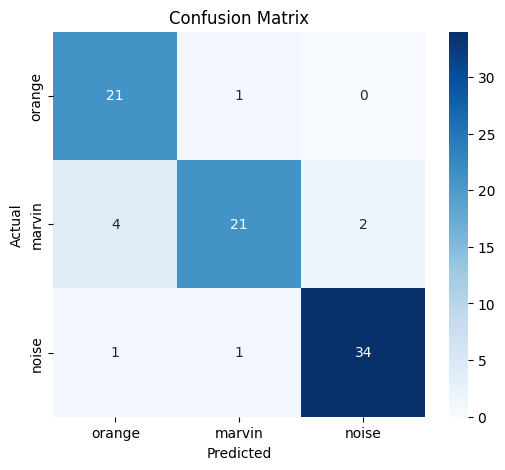

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['orange', 'marvin', 'noise']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import os

save_path = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_3"
os.makedirs(save_path, exist_ok=True)

model.save(os.path.join(save_path, "model.h5"))

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_3


### Measure Model Performance

In [ ]:
## Measure test-set accuracy manually and get values for confusion matrix
test_audio = []
test_labels = []
if is_batched(test_ds):
  was_batched=True
  test_ds = test_ds.unbatch()
else:
  was_batched=False
for audio, label in test_ds:
  test_audio.append(audio.numpy())
  test_labels.append(label.numpy())

test_audio = np.array(test_audio)
test_labels = np.array(test_labels)

model_out = model.predict(test_audio)
y_pred = np.argmax(model_out, axis=1)
y_true = test_labels

test_acc = sum(y_pred == y_true) / len(y_true)
print(f"Test set accuracy: {test_acc*100:.2f}%")
if was_batched:
  test_ds = test_ds.batch(32)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Test set accuracy: 89.41%


In [ ]:
n_macs = count_macs(model, verbose=False)
print(f"MACs: {n_macs}")

MACs: 91168


In [ ]:
tpr = np.nan*np.zeros(len(label_list))
fpr = np.nan*np.zeros(len(label_list))

for i in range(len(label_list)):
    tpr[i] = confusion_mtx[i,i] / np.sum(confusion_mtx[i,:])
    fpr[i] = (np.sum(confusion_mtx[:,i]) - confusion_mtx[i,i]) / \
             (np.sum(confusion_mtx) - np.sum(confusion_mtx[i,:]))

    print(f"True/False positive rate for '{label_list[i]:9}' = {tpr[i]:.3f} / {fpr[i]:.3f}")

True/False positive rate for 'orange   ' = 0.955 / 0.079
True/False positive rate for 'marvin   ' = 0.778 / 0.034
True/False positive rate for 'noise    ' = 0.944 / 0.041


In [ ]:
model_file_name = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_3/model.h5"

with open(model_file_name.split('.')[0] + '.txt', 'w') as fpo:
    fpo.write(f"i16min            = {i16min           }\n")
    fpo.write(f"i16max            = {i16max           }\n")
    fpo.write(f"fsamp             = {fsamp            }\n")
    fpo.write(f"wave_length_ms    = {wave_length_ms   }\n")
    fpo.write(f"wave_length_samps = {wave_length_samps}\n")
    fpo.write(f"window_size_ms    = {window_size_ms   }\n")
    fpo.write(f"window_step_ms    = {window_step_ms   }\n")
    fpo.write(f"num_filters       = {num_filters      }\n")
    fpo.write(f"use_microfrontend = {use_microfrontend}\n")
    fpo.write(f"label_list        = {label_list}\n")
    fpo.write(f"spectrogram_shape = {spectrogram.numpy().shape}\n")
    fpo.write(f"Est_MACs = {n_macs}\n")
    fpo.write(f"Test set accuracy =  {test_acc:.1%}\n")

    for i in range(len(label_list)):
        fpo.write(f"tpr_{label_list[i]:9} = {tpr[i]:.3}\n")
        fpo.write(f"fpr_{label_list[i]:9} = {fpr[i]:.3}\n")

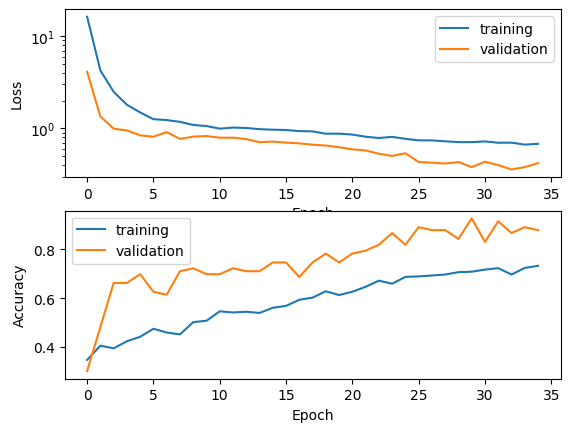

In [ ]:
metrics = history.history
plt.subplot(2,1,1)
plt.semilogy(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['training', 'validation'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.subplot(2,1,2)
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['training', 'validation'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [ ]:
## Measure test-set accuracy with the keras built-in function
test_loss, test_acc = model.evaluate(test_ds, verbose=2)

3/3 - 0s - 29ms/step - accuracy: 0.8941 - loss: 0.3723


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


On training set:
ds_labels[0] = 1
<class 'list'>
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step
Data set accuracy: 79%


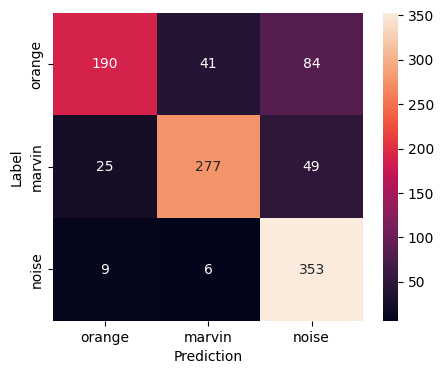

In [ ]:
dset = train_ds.unbatch()
print("On training set:")

ds_audio = []
ds_labels = []

for sample in dset:
  audio, label = sample[0], sample[1]
  ds_audio.append(audio.numpy())
  ds_labels.append(label.numpy())

print(f"ds_labels[0] = {ds_labels[0]}")
print(type(ds_labels))
ds_labels = np.array(ds_labels)
ds_audio = np.array(ds_audio)

model_out = model.predict(ds_audio)
y_pred = np.argmax(model_out, axis=1)
y_true = ds_labels

ds_acc = sum(y_pred == y_true) / len(y_true)
print(f'Data set accuracy: {ds_acc:.0%}')

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_mtx, xticklabels=label_list, yticklabels=label_list,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

ds_labels[0] = 2
<class 'list'>
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


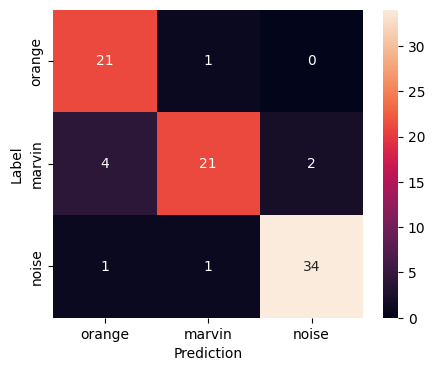

In [ ]:
def get_confusion_matrix(dset, model):
    # if is_batched(dset):
    #     dset = dset.unbatch()

    ds_audio = []
    ds_labels = []

    if is_batched(dset):
      dset = dset.unbatch()

    for sample in dset:
      audio, label = sample[0], sample[1]
      ds_audio.append(audio.numpy())
      ds_labels.append(label.numpy())

    print(f"ds_labels[0] = {ds_labels[0]}")
    print(type(ds_labels))

    ds_labels = np.array(ds_labels)
    ds_audio = np.array(ds_audio)

    model_out = model.predict(ds_audio)
    y_pred = np.argmax(model_out, axis=1)
    y_true = ds_labels

    # ds_acc = sum(y_pred == y_true) / len(y_true)
    confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
    return confusion_mtx

# print(f'Data set accuracy: {ds_acc:.0%}')

confusion_mtx = get_confusion_matrix(test_ds, model)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_mtx, xticklabels=label_list, yticklabels=label_list,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/orange")[:5])
print(os.listdir("/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/marvin")[:5])
print(os.listdir("/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/sound_samples/noise")[:5])

['orange_13F85B33_001.wav', 'orange_13F85B33_002.wav', 'orange_13F85B33_003.wav', 'orange_6B79F8FB_001.wav', 'orange_6B79F8FB_002.wav']
['cb802c63_nohash_1.wav', 'cd3331a6_nohash_1.wav', 'cc2f1a85_nohash_1.wav', 'c5570933_nohash_1.wav', 'cc554de3_nohash_1.wav']
['noise_13F85B33_001 (1).wav', 'noise_13F85B33_002 (1).wav', 'noise_13F85B33_003 (1).wav', 'noise_6B79F8FB_001 (1).wav', 'noise_6B79F8FB_002 (1).wav']


Processing 3 files
Added 0 silent wavs and ?? noisy wavs
About to create spectrograms from 3 waves
 0 wavs processed

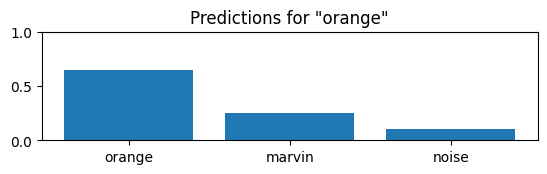

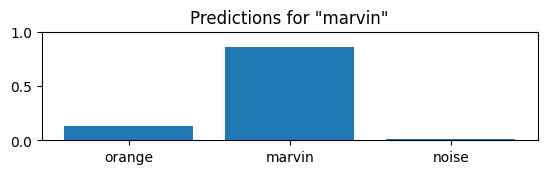

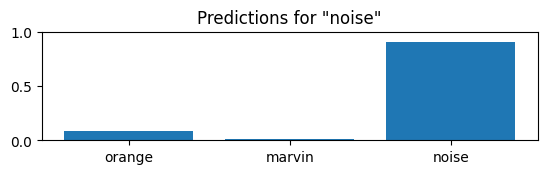

In [ ]:
sample_files = [
    data_dir/'orange/orange_13F85B33_003.wav',
    data_dir/'marvin/cd3331a6_nohash_1.wav',
    data_dir/'noise/noise_6B79F8FB_001 (1).wav'
]

fstr_list = [str(f) for f in sample_files]

sample_ds = preprocess_dataset(fstr_list, num_silent=0)

count = 1
for spectrogram, label in sample_ds.batch(1):
    prediction = model(spectrogram)

    plt.subplot(len(sample_files), 1, count)
    plt.bar(label_list, tf.nn.softmax(prediction[0]))
    plt.title(f'Predictions for "{label_list[label[0]]}"')
    plt.ylim([0,1])
    plt.show()

    count += 1

In [ ]:
label_list

['orange', 'marvin', 'noise']

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# INT8 quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# save it
tflite_path = "/content/drive/MyDrive/ML IoT Project 2: Keyword Spotter/model_3/model.tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

import os
size_kb = os.path.getsize(tflite_path) / 1024
print(f"TFLite model size: {size_kb:.2f} KB")

Saved artifact at '/tmp/tmpel6wcc_w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 32, 1), dtype=tf.float32, name='keras_tensor_78')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139376992203024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992203408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992204368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992203600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992204752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992204560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992205136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992204944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992205520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139376992205328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1393769922059

In [ ]:
fig, axes = plt.subplots(len(wt_list), 1, figsize=(6, 15))
for i, wt in enumerate(wt_list):
    sns.heatmap(conf_mat_list[i], xticklabels=label_list, yticklabels=label_list,
                annot=True, fmt='g', ax=axes[i])
    axes[i].set_title(f'Wt={wt}')
    axes[i].set_xlabel('Prediction')
    axes[i].set_ylabel('Label')
plt.tight_layout()

In [ ]:
# def confmat2pr(cm, target):

target = 2
tpr = np.nan*np.zeros(len(wt_list))
fpr = np.nan*np.zeros(len(wt_list))
prec = np.nan*np.zeros(len(wt_list))

for i in range(len(wt_list)):
    cm = conf_mat_list[i].numpy()
    # true pos rate = correctly recognized targets / all true targets
    tpr[i] = cm[target, target] / np.sum(cm[target,:]) # aka recall
    #fpr = false positives / all negatives
    fpr[i] = (np.sum(cm[:,target]) - cm[target,target]) / (np.sum(cm) - np.sum(cm[target,:]))
    # precision = true positives / predicted positives
    prec[i] = cm[target, target] / np.sum(cm[:,target]) # aka recall

    print(f"TPR/Recall = {tpr[i]}, FPR = {fpr[i]}, Precision={prec[i]}")
plt.plot(np.array(wt_list), tpr, np.array(wt_list), fpr)
plt.legend(['TPR', 'FPR'])
# plt.plot(prec, tpr, '.-')
# plt.xlabel('Precision (TP/PP)')
# plt.ylabel('Recall (TP/P)')
plt.grid(True)

In [ ]:
train_ds

In [ ]:
# model.summary()

model_l1 = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[0].output,
)

model_l1.summary()

In [ ]:
model.input.shape

In [ ]:
((wave_length_ms - window_size_ms) / window_step_ms) + 1

In [ ]:
# wave_length_ms = 1000
# wave_length_samps = int(wave_length_ms*fsamp/1000)
# window_size_ms=80
# window_step_ms=40

In [ ]:
60 * fsamp / 1000

In [ ]:
model.summary()

In [ ]:
model.input.shape[1]

In [ ]:
print(window_size_ms)
window_size_ms * fsamp / 1000

In [ ]:
!ls -l kws_ufe_31mar2022_2035.*

In [ ]:
model_tmp = tf.keras.models.load_model('kws_ufe_31mar2022_2035.h5')
n_macs = count_macs(model_tmp)
t_mac =  1.488e-07
print(f"Estimate {1000*n_macs*t_mac} ms / inf")

### 1D and Grouped Convolutions, Causal Padding

In [ ]:

m1 = tf.keras.Sequential([
  Input(shape=(20, 32, 1)),
  layers.Conv1D(25, 7, padding='valid')
])
m1.summary()


m2 = tf.keras.Sequential([
  Input(shape=(20, 32, 1)),
  layers.Conv1D(25, 7, padding='causal')
])
m2.summary()


m3 = tf.keras.Sequential([
  Input(shape=(20, 32, 1)),
  layers.Conv1D(25, 7, padding='same')
])
m3.summary()



In [ ]:

m2 = tf.keras.Sequential([
  Input(shape=(20, 32, 1)),
  layers.Conv2D(25, (1,7), padding='valid')
])
m2.summary()


In [ ]:
m4 = tf.keras.Sequential([
  Input(shape=(20, 32, 1)),
  layers.Conv1D(64, 7, padding='causal'),
  layers.Conv1D(64, 7, padding='causal')
])
m4.summary()

In [ ]:
m5 = tf.keras.Sequential([
  Input(shape=(20, 32)),
  layers.Conv1D(64, 7, padding='causal'),
  layers.Conv1D(64, 7, padding='causal', groups=4)
])
m5.summary()

In [ ]:
64*64

In [ ]:
m5 = tf.keras.Sequential([
  Input(shape=(20, 32)),
  layers.Conv1D(64, 7, padding='causal'),
  layers.Conv1D(64, 7, padding='causal', groups=64, use_bias=False),
  layers.Conv1D(64, 1, padding='causal')
])
m5.summary()

In [ ]:
m5 = tf.keras.Sequential([
  Input(shape=(25,16)),
  # no flatten
  layers.Dense(6)
])
m5.summary()

In [ ]:
20*np.log10(2500)

In [ ]:
model

In [ ]:
l = model.layers[-1]
print(l.weights[1])

In [ ]:
wts, bias = l.get_weights()

In [ ]:
bias[3] = 20
l.set_weights((wts, bias))

In [ ]:
print(l.weights[1])